# 📊 Dataset Information

**Note:** The dataset for this project is **not included in this repository** to keep the repository lightweight.  

You can download the dataset from **Kaggle** using the link below:  

[Download The Global Coffee Sales Dataset](https://www.kaggle.com/datasets/moezalikhan/global-coffee-shop-sales-dataset/data)  

Please make sure to place the downloaded CSV file in the same directory as this notebook before running any code.

# Importing

## Import Library

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

## Import CSV And convert to DataFrame

In [2]:
df = pd.read_csv('coffee_shop_sales.csv')

# Preprocessing

## Frist five row

In [3]:
df.head()

,transaction_id,timestamp,store_id,city,country,store_type,product_category,product_name,unit_price,quantity,discount_applied,payment_method,customer_id,customer_age_group,customer_gender,loyalty_member,weather_condition,temperature_c,holiday_name,total_amount
0,10001,2023-01-01 00:39:39,35,Melbourne,AUS,Mall Kiosk,Coffee,Double Espresso,3.04,1,True,Credit Card,qiyfrwsk,35-44,Female,False,Sunny,22.2,New Year's Day,2.74
1,10002,2023-01-01 01:06:53,25,Manchester,UK,Standalone,Coffee,Single Espresso,2.38,2,False,Debit Card,vf0jqqnv,18-24,Male,False,Sunny,8.7,New Year's Day,4.76
2,10003,2023-01-01 02:56:18,23,Manchester,UK,Standalone,Tea,Large Matcha Latte,4.26,2,False,Mobile Wallet,fcd6mzsg,25-34,Male,False,Sunny,8.7,New Year's Day,8.52
3,10004,2023-01-01 02:58:30,38,Toronto,CAN,Standalone,Coffee,Medium Cappuccino,3.68,2,False,Credit Card,jvu2cgxu,55-64,Female,True,Cloudy,-6.5,New Year's Day,7.36
4,10005,2023-01-01 03:13:53,9,Los Angeles,USA,Mall Kiosk,Coffee,Small Cappuccino,3.42,1,False,Mobile Wallet,po4ljedg,18-24,Male,True,Sunny,12.3,New Year's Day,3.42


## last Five row

In [4]:
df.tail()

,transaction_id,timestamp,store_id,city,country,store_type,product_category,product_name,unit_price,quantity,discount_applied,payment_method,customer_id,customer_age_group,customer_gender,loyalty_member,weather_condition,temperature_c,holiday_name,total_amount
19995,29996,2023-12-31 19:33:40,43,Vancouver,CAN,Standalone,Tea,Medium Chai Latte,3.95,1,True,Credit Card,ulmouymi,45-54,Male,False,Rainy,5.1,NaN,3.75
19996,29997,2023-12-31 19:34:58,24,Manchester,UK,Standalone,Coffee,Double Espresso,2.38,2,False,Mobile Wallet,xaj2t3z1,18-24,Male,True,Sunny,6.0,NaN,4.76
19997,29998,2023-12-31 19:37:34,13,Chicago,USA,Mall Kiosk,Sandwich,Chicken & Avocado Wrap,5.99,1,False,Cash,t2cfzn28,65+,Female,True,Sunny,-3.1,NaN,5.99
19998,29999,2023-12-31 19:53:35,16,London,UK,Standalone,Coffee,Large Mocha,4.42,1,False,Credit Card,u2tl08at,25-34,Female,False,Cloudy,7.0,NaN,4.42
19999,30000,2023-12-31 22:54:02,42,Vancouver,CAN,Standalone,Pastry,Scone,2.07,1,False,Cash,feq8sejr,55-64,Female,True,Rainy,5.1,NaN,2.07


## Shape of our dataset

In [5]:
df.shape

(20000, 20)

## List out all columns

In [6]:
df.columns

Index(['transaction_id', 'timestamp', 'store_id', 'city', 'country',
       'store_type', 'product_category', 'product_name', 'unit_price',
       'quantity', 'discount_applied', 'payment_method', 'customer_id',
       'customer_age_group', 'customer_gender', 'loyalty_member',
       'weather_condition', 'temperature_c', 'holiday_name', 'total_amount'],
      dtype='object')

## Datatype of each columns

In [7]:
df.dtypes

transaction_id          int64
timestamp              object
store_id                int64
city                   object
country                object
store_type             object
product_category       object
product_name           object
unit_price            float64
quantity                int64
discount_applied         bool
payment_method         object
customer_id            object
customer_age_group     object
customer_gender        object
loyalty_member           bool
weather_condition      object
temperature_c         float64
holiday_name           object
total_amount          float64
dtype: object

## Information of all Columns**

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   transaction_id      20000 non-null  int64  
 1   timestamp           20000 non-null  object 
 2   store_id            20000 non-null  int64  
 3   city                20000 non-null  object 
 4   country             20000 non-null  object 
 5   store_type          20000 non-null  object 
 6   product_category    20000 non-null  object 
 7   product_name        20000 non-null  object 
 8   unit_price          20000 non-null  float64
 9   quantity            20000 non-null  int64  
 10  discount_applied    20000 non-null  bool   
 11  payment_method      20000 non-null  object 
 12  customer_id         20000 non-null  object 
 13  customer_age_group  18924 non-null  object 
 14  customer_gender     18928 non-null  object 
 15  loyalty_member      20000 non-null  bool   
 16  weat

## Check Null Value

In [9]:
df.isnull().sum()

transaction_id            0
timestamp                 0
store_id                  0
city                      0
country                   0
store_type                0
product_category          0
product_name              0
unit_price                0
quantity                  0
discount_applied          0
payment_method            0
customer_id               0
customer_age_group     1076
customer_gender        1072
loyalty_member            0
weather_condition       978
temperature_c           978
holiday_name          19665
total_amount              0
dtype: int64

## drop unwanted column

In [10]:
df = df.drop(columns=['holiday_name'])

## separate numerical and categorical columns

In [11]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
cat_cols = df.select_dtypes(include=['object', 'bool']).columns

## fill numerical missing values with mean

In [12]:
for col in num_cols:
    df[col].fillna(df[col].mean(), inplace=True)

## fill categorical missing values with mode

In [13]:
for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

## check if any null values left

In [14]:
print(df.isnull().sum())

transaction_id        0
timestamp             0
store_id              0
city                  0
country               0
store_type            0
product_category      0
product_name          0
unit_price            0
quantity              0
discount_applied      0
payment_method        0
customer_id           0
customer_age_group    0
customer_gender       0
loyalty_member        0
weather_condition     0
temperature_c         0
total_amount          0
dtype: int64


## Check Dupicate Value

In [15]:
df.duplicated().sum()

np.int64(0)

## Summary

In [16]:
df.describe()

,transaction_id,store_id,unit_price,quantity,temperature_c,total_amount
count,20000.000000,20000.000000,20000.000000,20000.00000,20000.000000,20000.000000
mean,20000.500000,23.072950,4.049521,1.71265,13.556550,6.850464
std,5773.647028,13.097332,1.982984,1.10808,7.982242,5.989221
min,10001.000000,1.000000,1.640000,1.00000,-11.000000,1.310000
25%,15000.750000,12.000000,2.820000,1.00000,8.000000,3.360000
50%,20000.500000,23.000000,3.690000,1.00000,14.000000,4.920000
75%,25000.250000,34.000000,4.750000,2.00000,19.500000,8.200000
max,30000.000000,45.000000,18.750000,9.00000,32.600000,112.000000


# EDA

In [17]:
def show_fig():
    plt.tight_layout()
    plt.show()

plot_no = 1

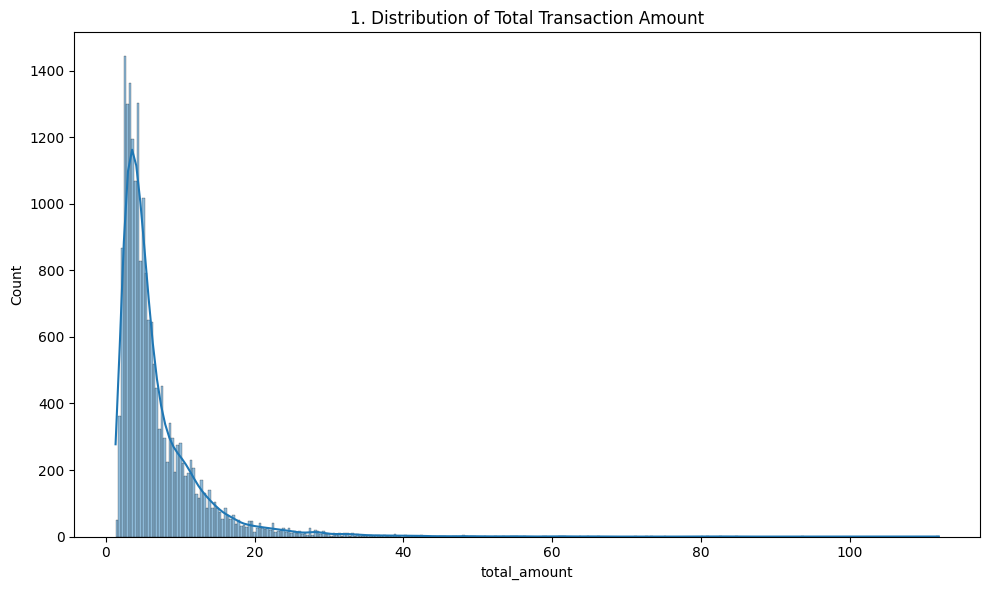

In [18]:
fig = plt.figure(figsize=(10,6))
sns.histplot(df['total_amount'], kde=True)
plt.title(f'{plot_no}. Distribution of Total Transaction Amount')
show_fig()
plot_no += 1

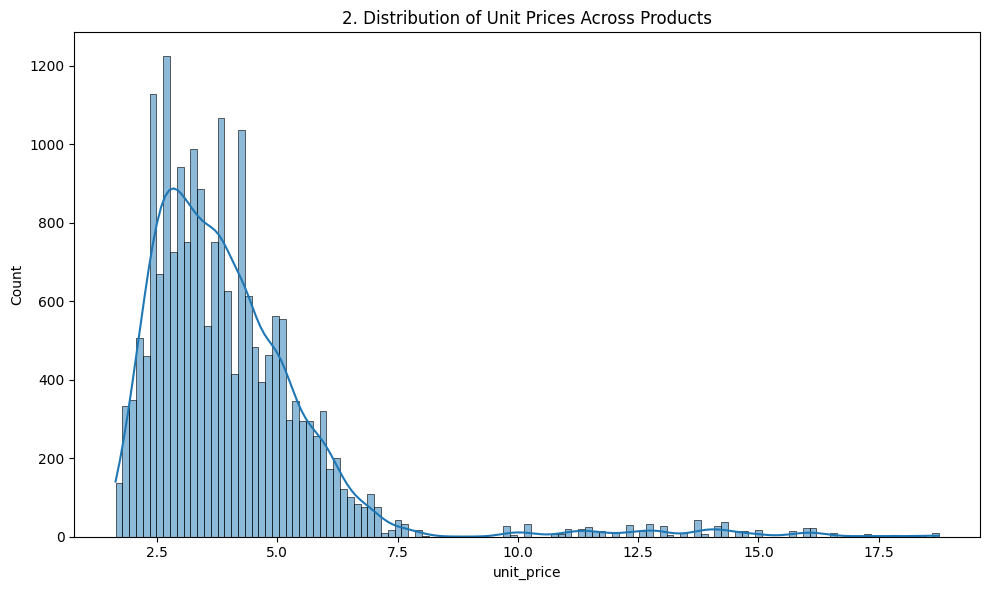

In [19]:
fig = plt.figure(figsize=(10,6))
sns.histplot(df['unit_price'], kde=True)
plt.title(f'{plot_no}. Distribution of Unit Prices Across Products')
show_fig()
plot_no += 1

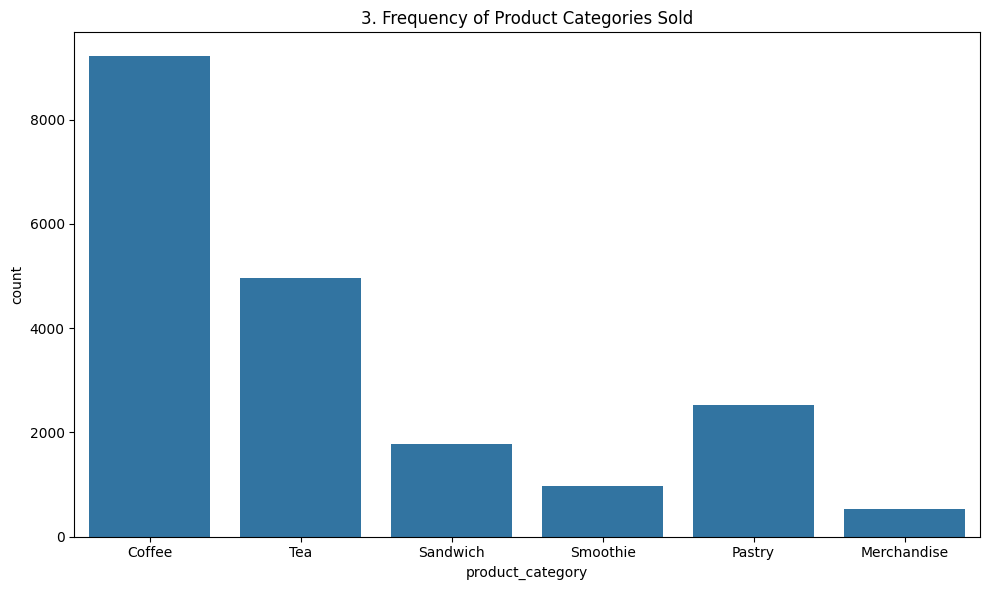

In [20]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, x='product_category')
plt.title(f'{plot_no}. Frequency of Product Categories Sold')
show_fig()
plot_no += 1

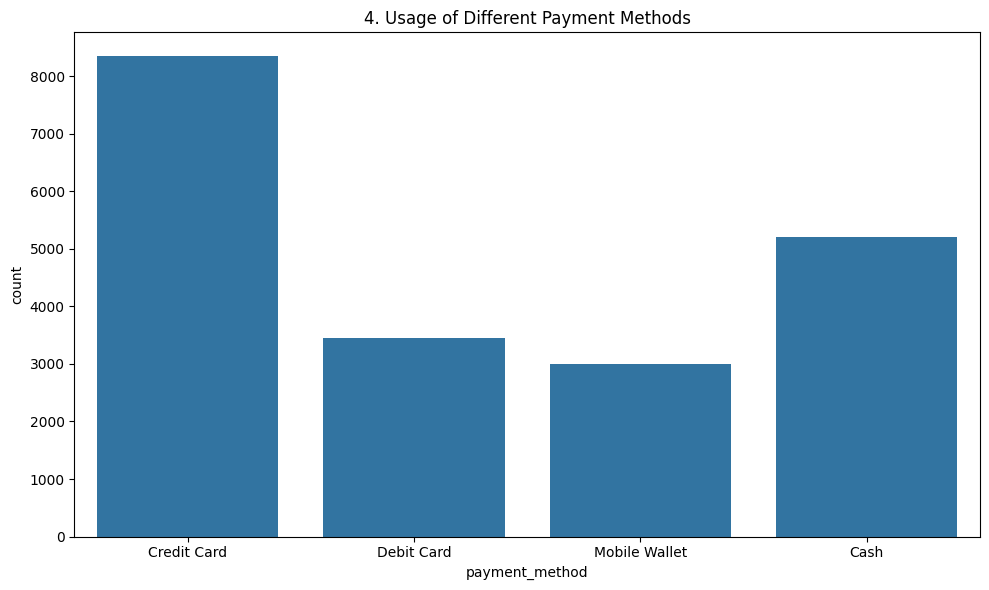

In [21]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, x='payment_method')
plt.title(f'{plot_no}. Usage of Different Payment Methods')
show_fig()
plot_no += 1

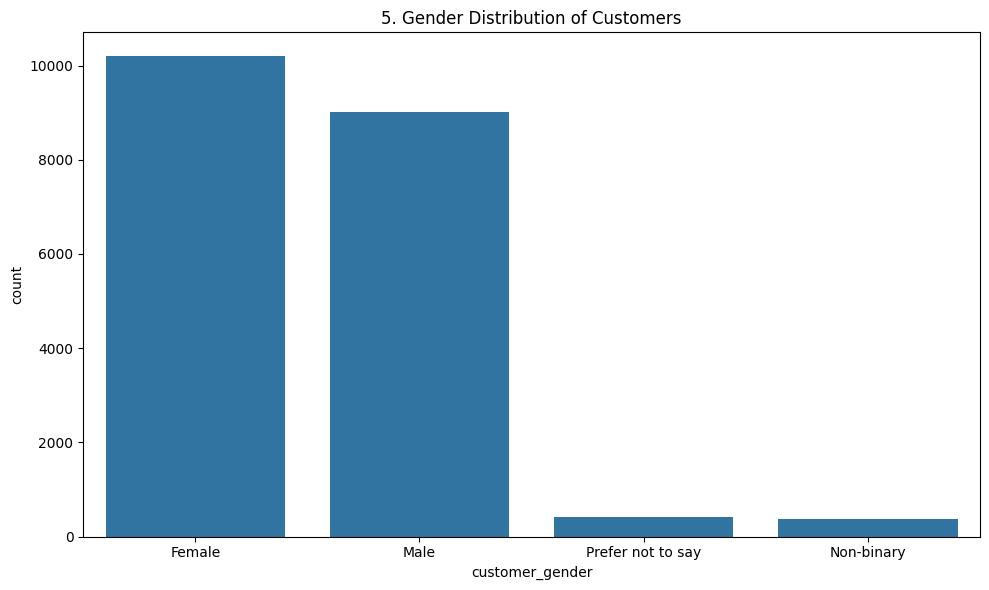

In [22]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, x='customer_gender')
plt.title(f'{plot_no}. Gender Distribution of Customers')
show_fig()
plot_no += 1

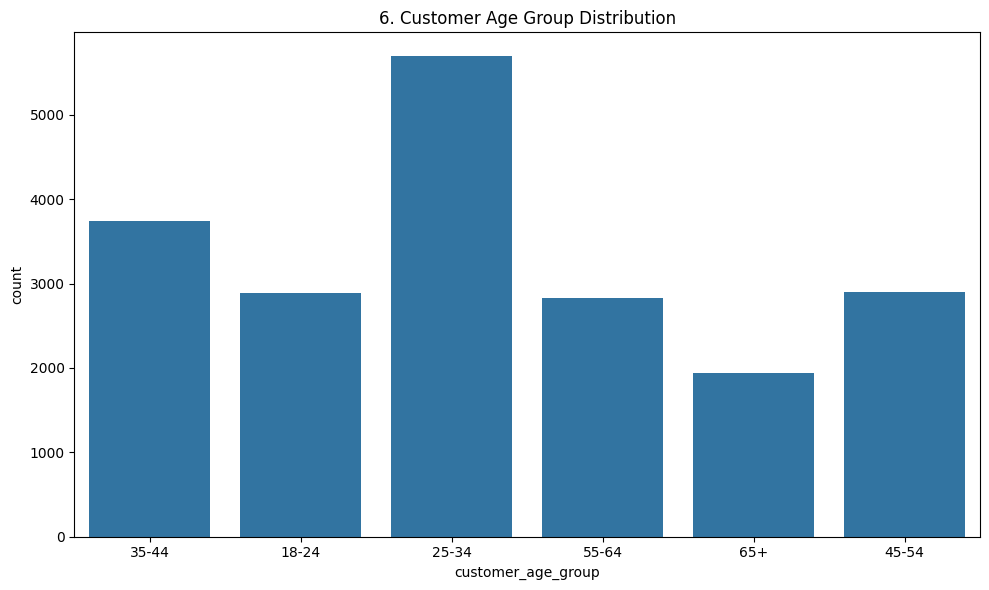

In [23]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, x='customer_age_group')
plt.title(f'{plot_no}. Customer Age Group Distribution')
show_fig()
plot_no += 1

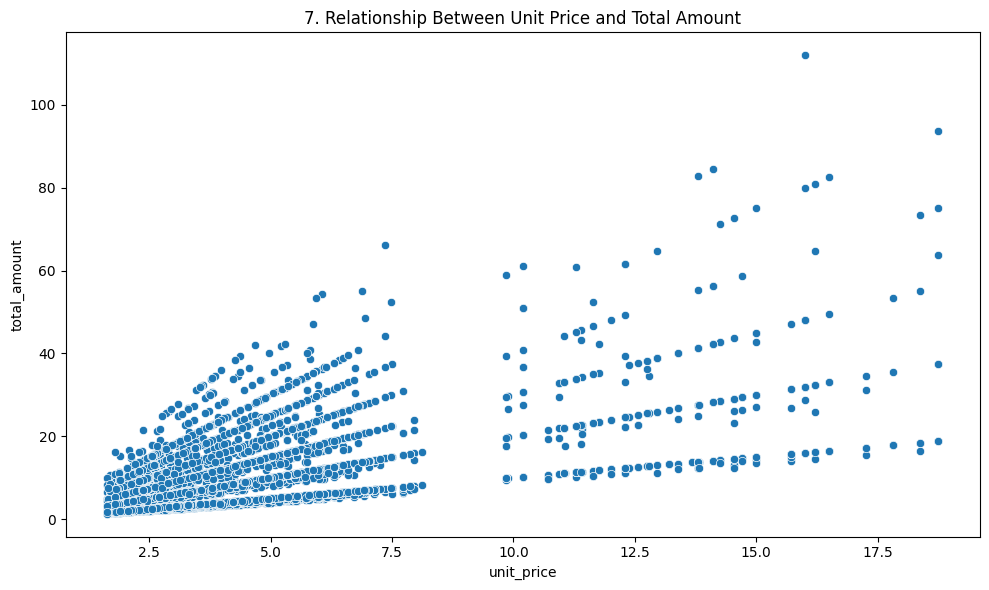

In [24]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='unit_price', y='total_amount')
plt.title(f'{plot_no}. Relationship Between Unit Price and Total Amount')
show_fig()
plot_no += 1

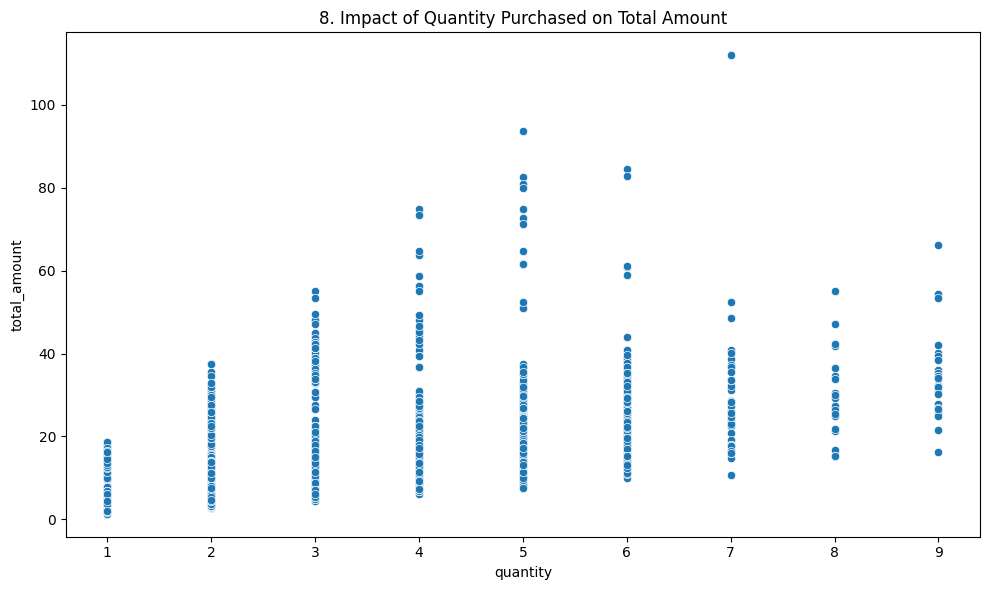

In [25]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='quantity', y='total_amount')
plt.title(f'{plot_no}. Impact of Quantity Purchased on Total Amount')
show_fig()
plot_no += 1

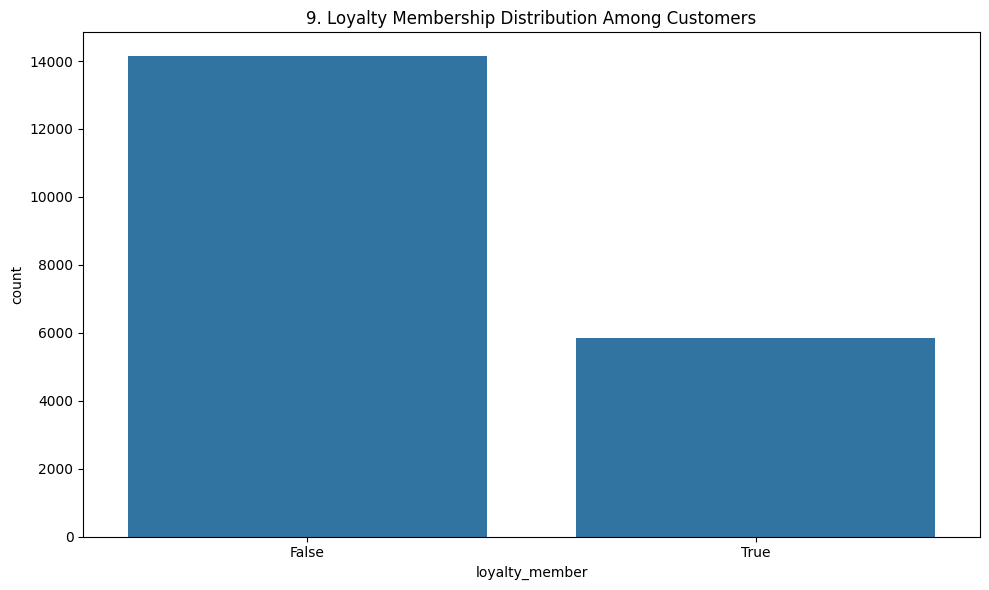

In [26]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, x='loyalty_member')
plt.title(f'{plot_no}. Loyalty Membership Distribution Among Customers')
show_fig()
plot_no += 1

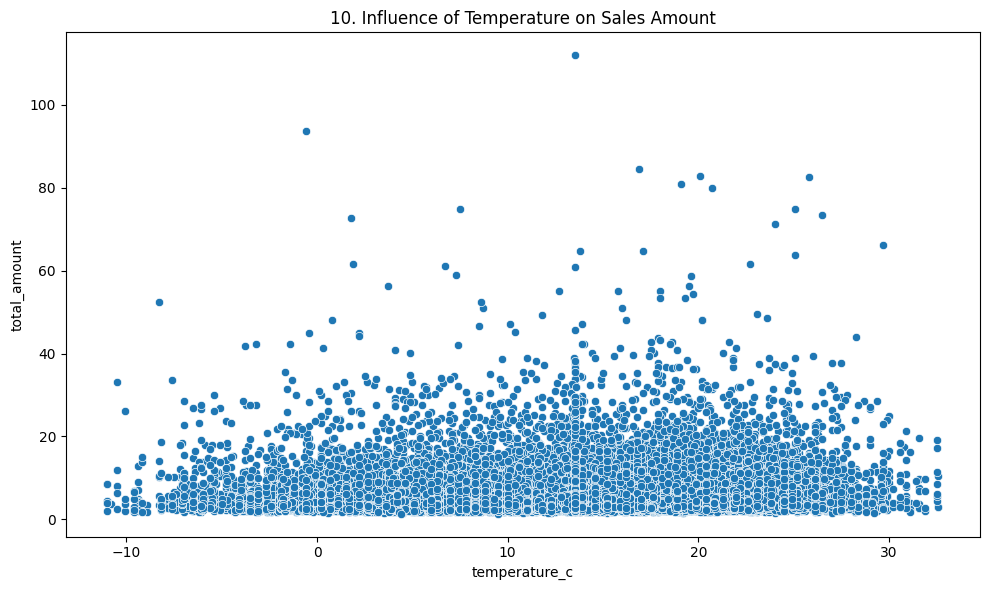

In [27]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='temperature_c', y='total_amount')
plt.title(f'{plot_no}. Influence of Temperature on Sales Amount')
show_fig()
plot_no += 1

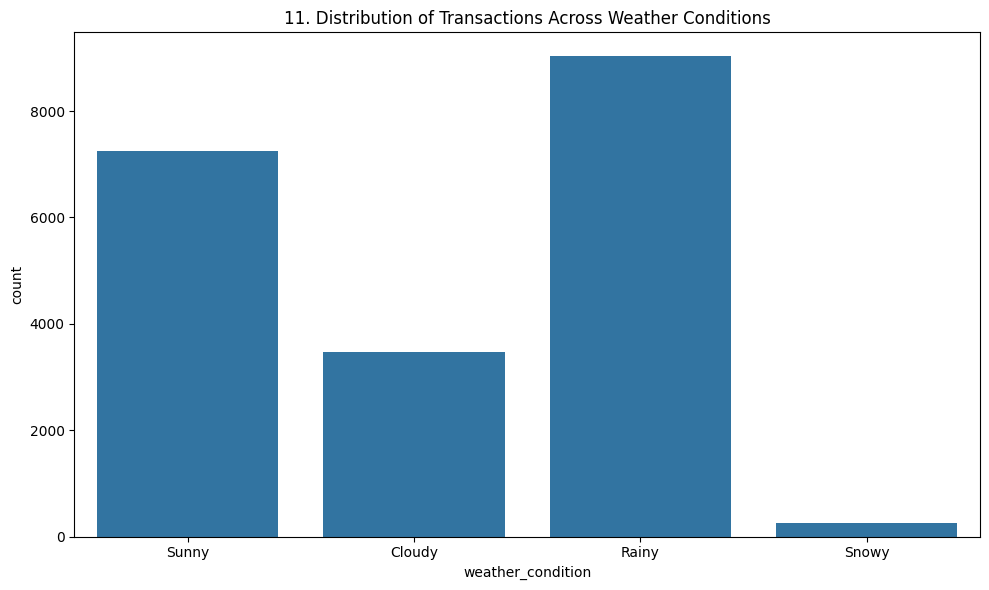

In [28]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, x='weather_condition')
plt.title(f'{plot_no}. Distribution of Transactions Across Weather Conditions')
show_fig()
plot_no += 1

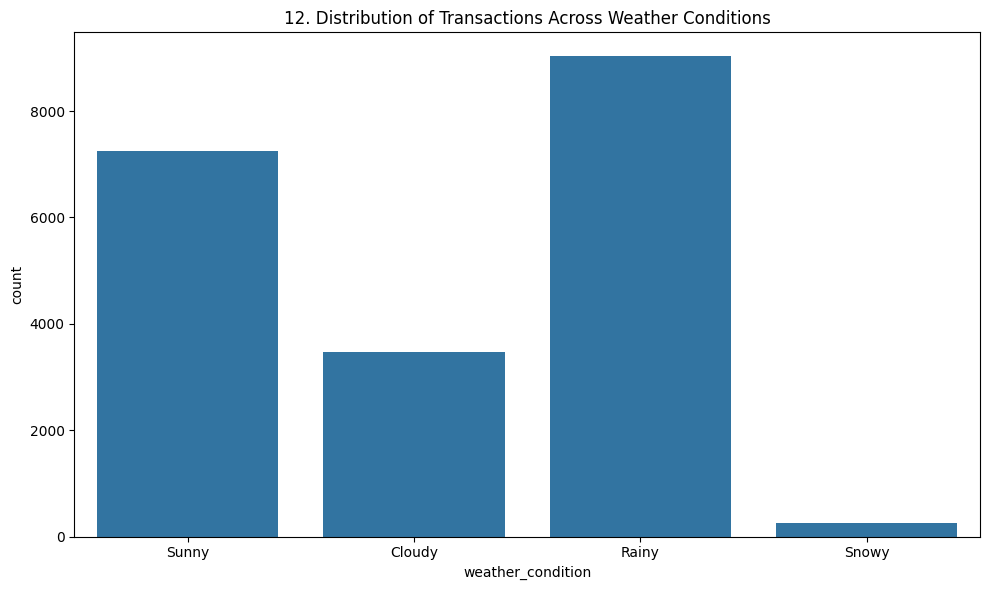

In [29]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, x='weather_condition')
plt.title(f'{plot_no}. Distribution of Transactions Across Weather Conditions')
show_fig()
plot_no += 1

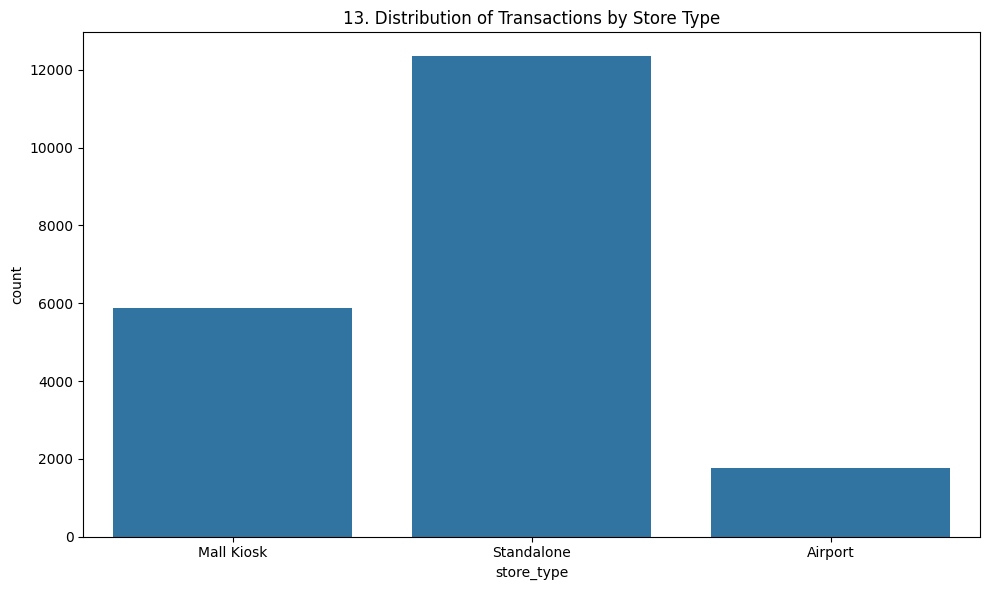

In [30]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, x='store_type')
plt.title(f'{plot_no}. Distribution of Transactions by Store Type')
show_fig()
plot_no += 1

# Model Training

## create a copy of dataset

In [31]:
data = df.copy()

## drop unnecessary columns

In [32]:
data = data.drop(['transaction_id','timestamp','customer_id'], axis=1)

## convert boolean to int

In [33]:
data['discount_applied'] = data['discount_applied'].astype(int)
data['loyalty_member'] = data['loyalty_member'].astype(int)

## encode categorical variables

In [34]:
le = LabelEncoder()
for col in data.select_dtypes(include='object').columns:
    data[col] = le.fit_transform(data[col])

## create target variable

In [35]:
data['target'] = (data['total_amount'] > data['total_amount'].median()).astype(int)

## define features and target

In [36]:
X = data.drop(['total_amount','target'], axis=1)
y = data['target']

## split dataset

In [37]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## scale numerical features

In [38]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## train model (Logistic Regression)

In [39]:
model = LogisticRegression()
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


## make predictions

In [40]:
y_pred = model.predict(X_test)

## print accuracy

In [41]:
print("Accuracy Score:", accuracy_score(y_test, y_pred))

Accuracy Score: 0.991


## plot confusion matrix

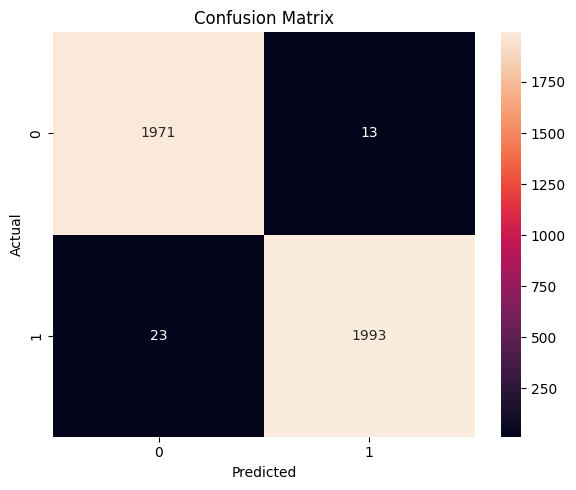

In [42]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()